# Projet COVID 19 : Modelisation Random Forest - 4 classes - Balanced - 3ème itération

## Conditions de modélisation

## Environnement de travail

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
import joblib

In [2]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Racine du projet (Liora_Covid)
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent.parent

# Dossier des CSV
DATA_DIR = PROJECT_ROOT / "csv"

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_ROOT)
print("CSV      :", DATA_DIR)

Notebook : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\notebooks\Modelisation\Random Forest
Projet   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid
CSV      : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\csv


In [3]:
# Chargement des données
train = pd.read_csv(DATA_DIR / "train_features.csv")
validation = pd.read_csv(DATA_DIR / "validation_features.csv")
test = pd.read_csv(DATA_DIR / "test_features.csv")

print(f"\nTrain      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")


Train      : (16668, 6)
Validation : (2083, 6)
Test       : (2084, 6)


## Définition de la cible et des features

In [4]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

## Vérification des classes

In [5]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal             0.486501
Lung_Opacity       0.287437
COVID              0.161867
Viral Pneumonia    0.064195
Name: proportion, dtype: float64

Distribution validation :
classe
Normal             0.486318
Lung_Opacity       0.287086
COVID              0.162266
Viral Pneumonia    0.064330
Name: proportion, dtype: float64

Distribution test :
classe
Normal             0.486564
Lung_Opacity       0.287428
COVID              0.161708
Viral Pneumonia    0.064299
Name: proportion, dtype: float64


## Pipeline Random Forest

In [6]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1
    ))
])

## Grille des Hyperparamètres

In [7]:
param_grid_v3 = {
    "model__n_estimators": [200],
    "model__max_depth": [15, 20, 25],
    "model__min_samples_split": [10, 15, 20],
    "model__min_samples_leaf": [2, 3, 4, 5],
    "model__max_features": ["sqrt"]
}

## Cross-validation stratifiée + GridSearch

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_v3,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=0))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [15, 20, 25],
                         'model__max_features': ['sqrt'],
                         'model__min_samples_leaf': [2, 3, 4, 5],
                         'model__min_samples_split': [10, 15, 20],
                         'model__n_estimators': [200]},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [9]:
# Meilleurs paramètres

print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur score F1 moyen en cross-validation :")
print(grid_rf.best_score_)

Meilleurs paramètres :
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 15, 'model__n_estimators': 200}

Meilleur score F1 moyen en cross-validation :
0.4772621698410144


In [10]:
# Résultats de la GridSearch

results = pd.DataFrame(grid_rf.cv_results_)
results = results.sort_values("rank_test_score")

results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
19,1,0.477262,0.009253,0.771552,0.003490,"{'model__max_depth': 20, 'model__max_features'..."
13,2,0.477022,0.008640,0.797025,0.002876,"{'model__max_depth': 20, 'model__max_features'..."
15,3,0.476808,0.008776,0.841195,0.003905,"{'model__max_depth': 20, 'model__max_features'..."
18,4,0.476660,0.010115,0.821536,0.004553,"{'model__max_depth': 20, 'model__max_features'..."
11,5,0.476385,0.009235,0.691812,0.001786,"{'model__max_depth': 15, 'model__max_features'..."
7,6,0.476181,0.008106,0.728888,0.002703,"{'model__max_depth': 15, 'model__max_features'..."
2,7,0.476173,0.009021,0.711518,0.001636,"{'model__max_depth': 15, 'model__max_features'..."
17,8,0.476039,0.011754,0.741276,0.003226,"{'model__max_depth': 20, 'model__max_features'..."
22,9,0.475983,0.009756,0.757712,0.002274,"{'model__max_depth': 20, 'model__max_features'..."
31,10,0.475940,0.008591,0.778695,0.003477,"{'model__max_depth': 25, 'model__max_features'..."


## Évaluation sur validation

### Classification report

In [11]:
best_rf = grid_rf.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.5626500240038406
Balanced accuracy : 0.4891341324554632
Precision macro : 0.45482965034706835
Recall macro : 0.4891341324554632
F1-score macro : 0.4641777272290792
F1-score weighted : 0.5550205510765818

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.25      0.17      0.20       338
   Lung_Opacity       0.54      0.56      0.55       598
         Normal       0.69      0.70      0.69      1013
Viral Pneumonia       0.33      0.53      0.41       134

       accuracy                           0.56      2083
      macro avg       0.45      0.49      0.46      2083
   weighted avg       0.55      0.56      0.56      2083



### Matrice de confusion

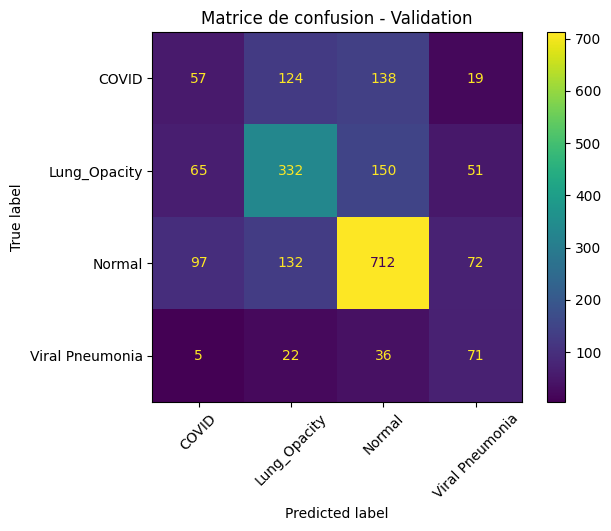

In [12]:
cm = confusion_matrix(y_val, y_val_pred)
class_names = best_rf.named_steps["model"].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Validation")
plt.show()

### Features importance

In [13]:
rf_model = best_rf.named_steps["model"]

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
0,lum_interieur_masque,0.355198
3,variance_laplacien,0.298962
2,surface_masque,0.194325
1,lum_exterieur_masque,0.151515


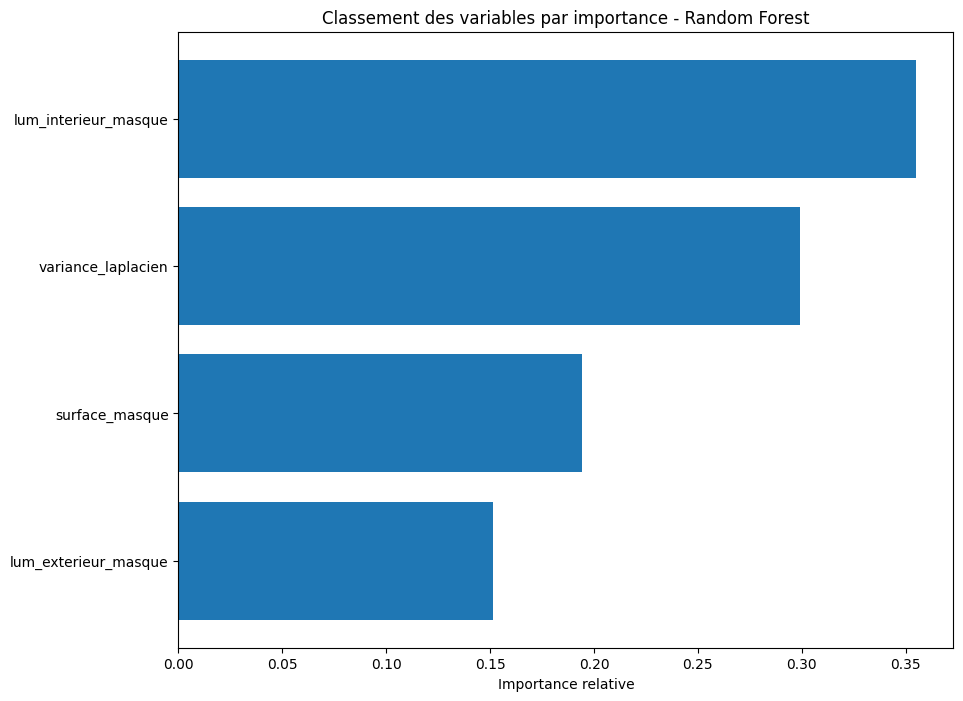

In [14]:
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["importance"][::-1]
)
plt.xlabel("Importance relative")
plt.title("Classement des variables par importance - Random Forest")
plt.show()

### Permutation importance

In [15]:
perm_importance = permutation_importance(
    best_rf,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

In [16]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

perm_df.head(20)

,feature,importance_mean,importance_std
0,variance_laplacien,0.154009,0.011674
1,lum_interieur_masque,0.091754,0.007556
2,surface_masque,0.058213,0.007454
3,lum_exterieur_masque,0.008156,0.006685


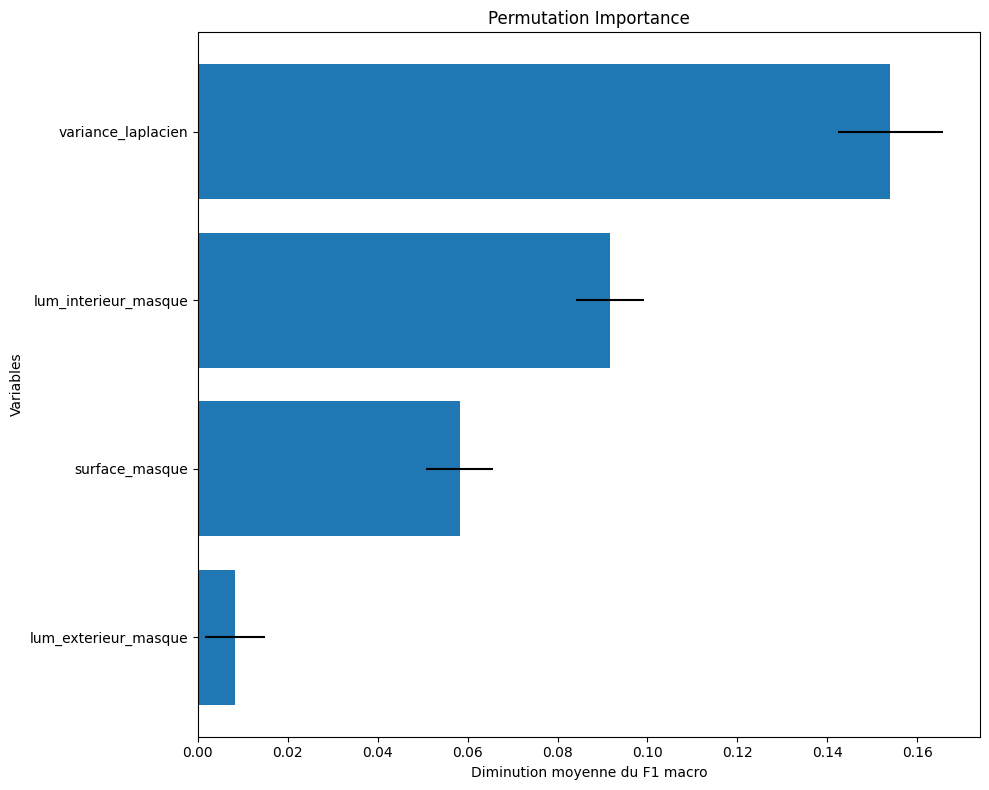

In [17]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["feature"][:20][::-1],
    perm_df["importance_mean"][:20][::-1],
    xerr=perm_df["importance_std"][:20][::-1]
)

plt.xlabel("Diminution moyenne du F1 macro")
plt.ylabel("Variables")
plt.title("Permutation Importance")

plt.tight_layout()
plt.show()

In [18]:
# Ordre exact des classes dans les colonnes de predict_proba
class_names = best_rf.classes_

print("Ordre des classes :", class_names)
print("Forme de y_val_proba :", y_val_proba.shape)
print("Nombre d'observations :", len(y_val))

assert y_val_proba.shape[0] == len(y_val)
assert y_val_proba.shape[1] == len(class_names)

Ordre des classes : ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']
Forme de y_val_proba : (2083, 4)
Nombre d'observations : 2083


## Test du modèle

### Classification report

In [19]:
final_model = best_rf

y_test_pred = final_model.predict(X_test)

print("Évaluation finale sur le jeu de test")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision macro :", precision_score(y_test, y_test_pred, average="macro"))
print("Recall macro :", recall_score(y_test, y_test_pred, average="macro"))
print("F1-score macro :", f1_score(y_test, y_test_pred, average="macro"))
print("F1-score weighted :", f1_score(y_test, y_test_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_test, y_test_pred))

Évaluation finale sur le jeu de test
Accuracy : 0.5743761996161229
Balanced accuracy : 0.5257639942519726
Precision macro : 0.48190119683069843
Recall macro : 0.5257639942519726
F1-score macro : 0.49125705462554503
F1-score weighted : 0.5692034245820814

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.33      0.22      0.26       337
   Lung_Opacity       0.53      0.55      0.54       599
         Normal       0.70      0.70      0.70      1014
Viral Pneumonia       0.36      0.63      0.46       134

       accuracy                           0.57      2084
      macro avg       0.48      0.53      0.49      2084
   weighted avg       0.57      0.57      0.57      2084



### Matrice de confusion

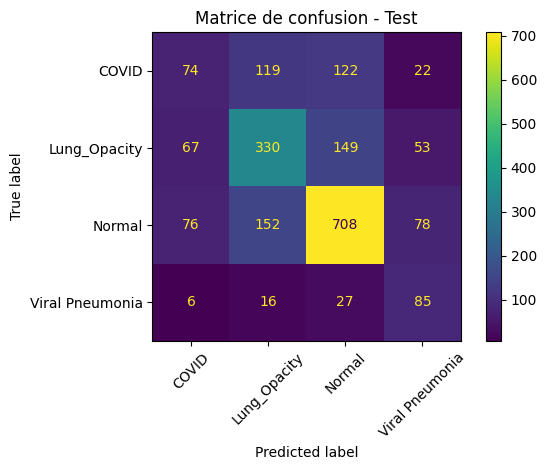

In [20]:
cm_test = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Test")
plt.tight_layout()
plt.show()

## Courbes Precision / Recall

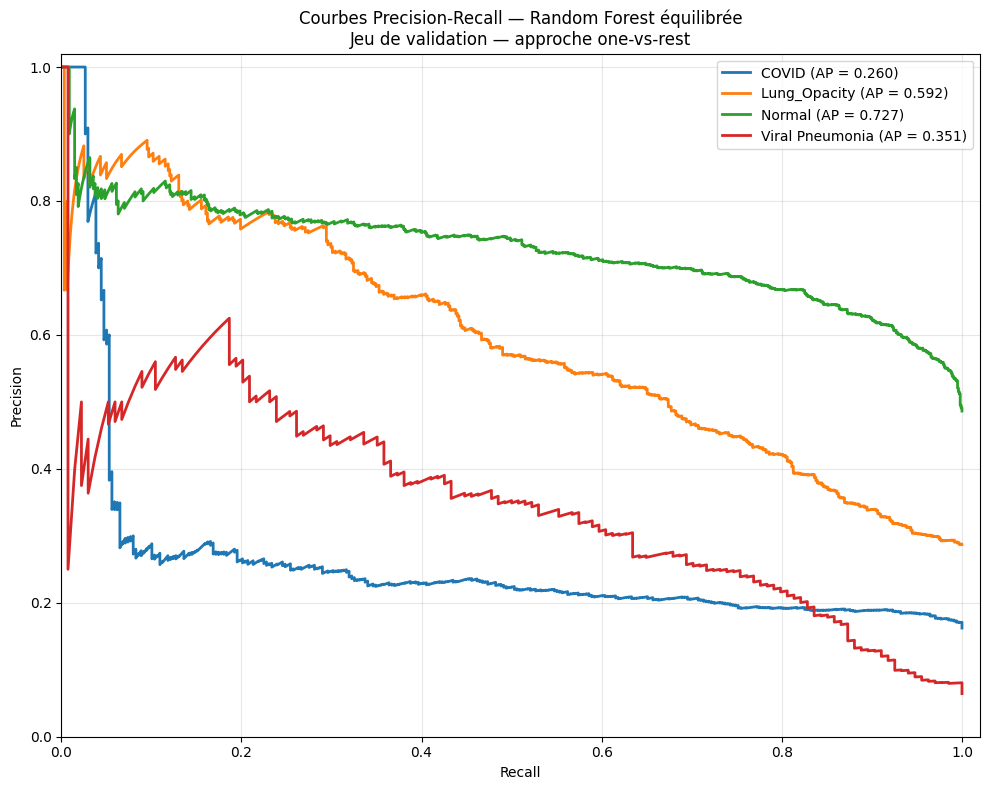

In [21]:
# Courbes Precision / Recall des 4 classes

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    # Transformation one-vs-rest :
    # 1 pour la classe étudiée, 0 pour toutes les autres
    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    # Probabilité attribuée à cette classe
    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    average_precision = average_precision_score(
        y_true_binary,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — Random Forest équilibrée\n"
    "Jeu de validation — approche one-vs-rest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

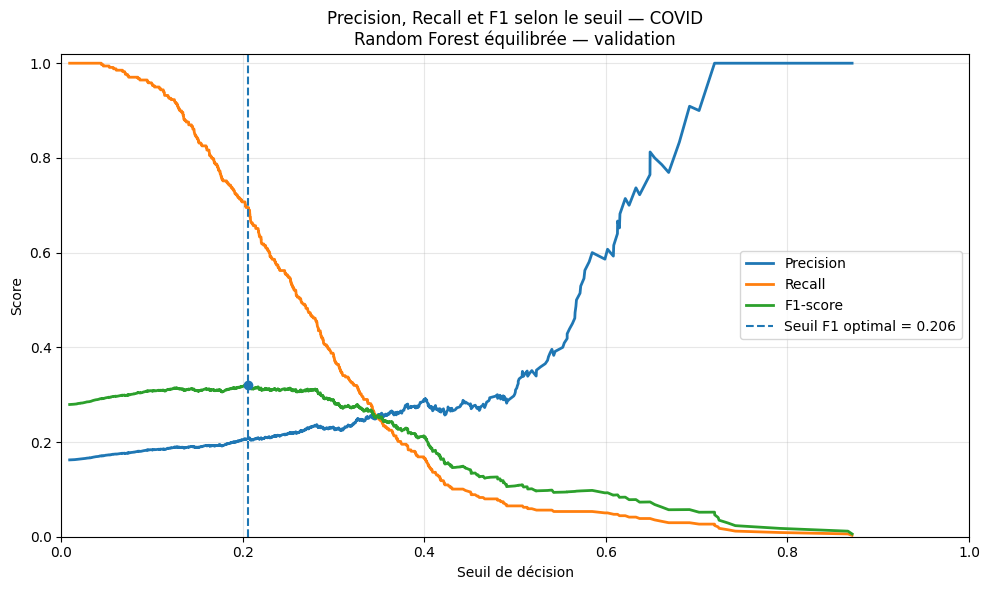

Classe : COVID
Seuil optimal : 0.2062
Precision : 0.2085
Recall : 0.6953
F1-score : 0.3208
--------------------------------------------------


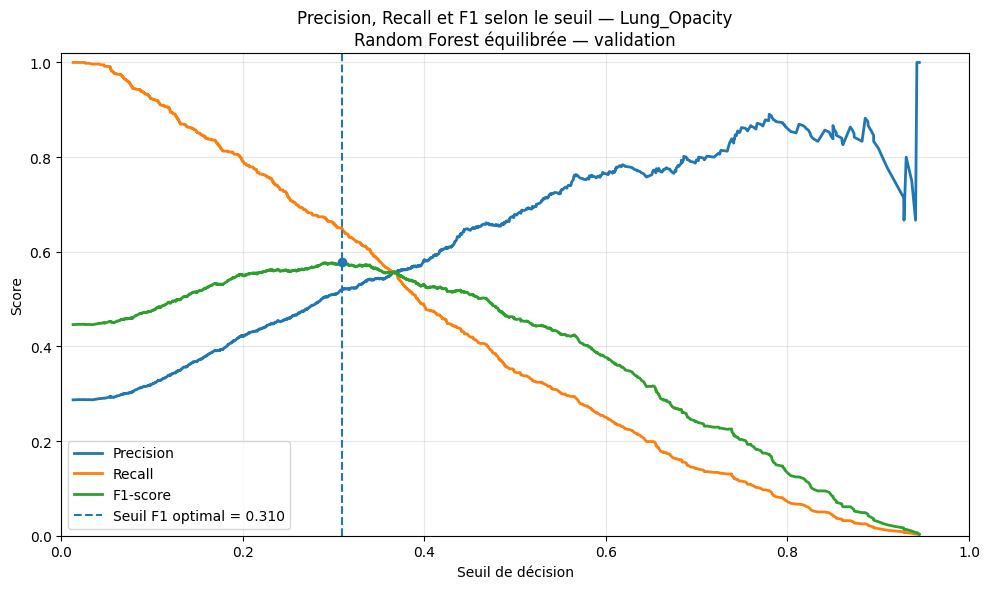

Classe : Lung_Opacity
Seuil optimal : 0.3097
Precision : 0.5215
Recall : 0.6488
F1-score : 0.5782
--------------------------------------------------


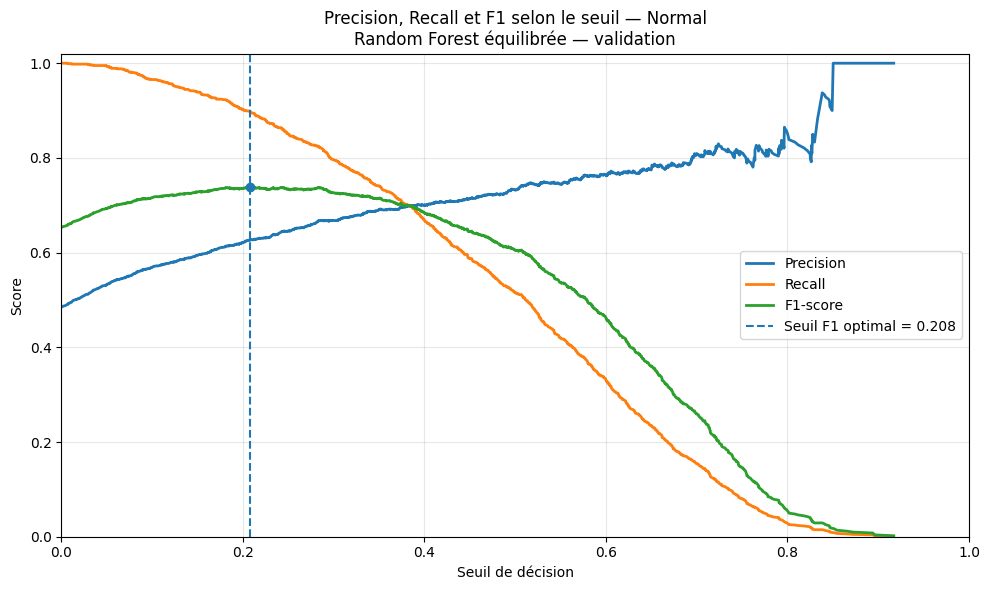

Classe : Normal
Seuil optimal : 0.2085
Precision : 0.6273
Recall : 0.8973
F1-score : 0.7384
--------------------------------------------------


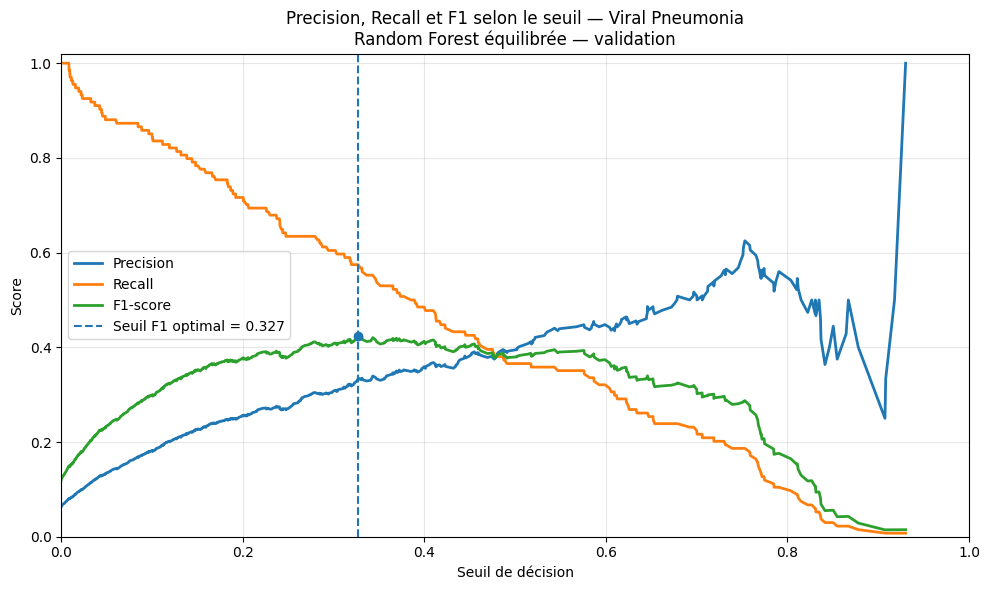

Classe : Viral Pneumonia
Seuil optimal : 0.3270
Precision : 0.3348
Recall : 0.5746
F1-score : 0.4231
--------------------------------------------------


In [22]:
# Precision, Recall et F1 en fonction du seuil

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    # precision et recall contiennent une valeur de plus
    # que thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    best_threshold = thresholds[best_index]
    best_precision = precision_by_threshold[best_index]
    best_recall = recall_by_threshold[best_index]
    best_f1 = f1_by_threshold[best_index]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "Random Forest équilibrée — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(f"Seuil optimal : {best_threshold:.4f}")
    print(f"Precision : {best_precision:.4f}")
    print(f"Recall : {best_recall:.4f}")
    print(f"F1-score : {best_f1:.4f}")
    print("-" * 50)

In [23]:
# Récapitulatif des seuils optimaux

threshold_results_rf = []

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    threshold_results_rf.append({
        "classe": class_name,
        "index_classe": class_index,
        "seuil_optimal_f1": thresholds[best_index],
        "precision_validation": precision_by_threshold[best_index],
        "recall_validation": recall_by_threshold[best_index],
        "f1_validation": f1_by_threshold[best_index],
        "average_precision": average_precision_score(
            y_true_binary,
            y_score
        )
    })

threshold_results_rf_df = pd.DataFrame(
    threshold_results_rf
).round(4)

threshold_results_rf_df

,classe,index_classe,seuil_optimal_f1,precision_validation,recall_validation,f1_validation,average_precision
0,COVID,0,0.2062,0.2085,0.6953,0.3208,0.2596
1,Lung_Opacity,1,0.3097,0.5215,0.6488,0.5782,0.5916
2,Normal,2,0.2085,0.6273,0.8973,0.7384,0.7267
3,Viral Pneumonia,3,0.3270,0.3348,0.5746,0.4231,0.3514
